In [1]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
os.getcwd()

'/home/skandabhairava/Desktop/MFT_FL/notebooks'

In [6]:
# Define your known tags (easy to expand anytime)
KNOWN_TAGS = {
    "attack_type": ["backdoor", "lblswitch", "majoritybyz", "subtle", "alie", "normal"],
    "protocol_type": ["fedattract", "cap", "fedavg"],
    "data_type": ["pathalogical", "pathological", "d0-3", "d100", "dropout50"]
}

def extract_metadata(folder_name):
    name_lower = folder_name.lower()
    meta = {}
    for category, tags in KNOWN_TAGS.items():
        found = [tag for tag in tags if tag in name_lower]
        meta[category] = found[0] if found else "unknown"
    return meta

def parse_run_log(log_path):
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    # Client breakdown
    client_matches = re.findall(r"Client\s+\d+\s+has been assigned type:\s*([^\r\n]+)", content)
    normal_count = sum(1 for c in client_matches if c.strip() == "normal")
    total_clients = len(client_matches)
    malicious_count = total_clients - normal_count
    normal_pct = (normal_count / total_clients * 100) if total_clients > 0 else 0.0

    client_stats = {
        "total_clients": total_clients,
        "normal_clients": normal_count,
        "malicious_clients": malicious_count,
        "normal_pct": normal_pct,
        "malicious_pct": 100 - normal_pct if total_clients > 0 else 0.0
    }

    # Rounds breakdown
    rounds_data = []
    round_blocks = re.split(r"(?:\n|^)\s*(\d+)/\d+:\s*", content)
    
    if len(round_blocks) > 1:
        for i in range(1, len(round_blocks), 2):
            epoch = int(round_blocks[i])
            block = round_blocks[i + 1]

            train_time = re.search(r"Time taken to train:\s*([\d\.]+)s", block)
            bigo_time = re.search(r"Big O time:\s*(\d+)", block)
            bigo_space = re.search(r"Big O space:\s*(\d+)", block)
            algo_time = re.search(r"Time taken algorithm model:\s*([\d\.]+)", block)
            eval_acc = re.search(r"Accuracy:\s*([\d\.]+)%", block)

            rounds_data.append({
                "epoch": epoch,
                "train_time_s": float(train_time.group(1)) if train_time else None,
                "eval_accuracy": float(eval_acc.group(1)) if eval_acc else None,
                "bigo_time": int(bigo_time.group(1)) if bigo_time else None,
                "bigo_space": int(bigo_space.group(1)) if bigo_space else None,
                "algo_time_s": float(algo_time.group(1)) if algo_time else None
            })

    return client_stats, pd.DataFrame(rounds_data)

def load_all_runs(root_dir="./"):
    records = []
    for entry in os.scandir(root_dir):
        if entry.is_dir() and entry.name.startswith("RUN_"):
            log_path = Path(entry.path) / "run.log"
            if log_path.exists():
                meta = extract_metadata(entry.name)
                client_stats, df_rounds = parse_run_log(log_path)
                records.append({
                    "folder_name": entry.name,
                    **meta,
                    **client_stats,
                    "df_rounds": df_rounds
                })
    return pd.DataFrame(records)

# Load into memory once
DF_RUNS = load_all_runs(root_dir="../logs/")

In [23]:
def analyze_run(attack=None, protocol=None, data_type=None, run_index=0, steps_split_fedattract=5):
    """
    Filters runs based on chosen variables and displays stats + plots.
    Pass None to any argument to leave it unconstrained.
    """
    filtered = DF_RUNS.copy()
    
    if attack:
        filtered = filtered[filtered["attack_type"] == attack.lower()]
    if protocol:
        filtered = filtered[filtered["protocol_type"] == protocol.lower()]
    if data_type:
        filtered = filtered[filtered["data_type"] == data_type.lower()]
        
    if filtered.empty:
        print(f"No runs found matching: attack='{attack}', protocol='{protocol}', data_type='{data_type}'")
        return None
    
    if len(filtered) > 1:
        print(f"Found {len(filtered)} matching runs. Displaying run index {run_index}:")
        
    row = filtered.iloc[run_index]
    df_rounds = row["df_rounds"]

    # 1. Print Client Stats
    print("=" * 65)
    print(f"RUN: {row['folder_name']}")
    print(f"Configuration -> Attack: {row['attack_type']} | Protocol: {row['protocol_type']} | Data: {row['data_type']}")
    print("-" * 65)
    print(f"Total Clients:     {row['total_clients']}")
    print(f"Normal Clients:    {row['normal_clients']} ({row['normal_pct']:.2f}%)")
    print(f"Malicious Clients: {row['malicious_clients']} ({row['malicious_pct']:.2f}%)")
    print("=" * 65)

    if protocol == "fedattract":
        splits_vline_idx = list(range(0, len(df_rounds["epoch"])+1, steps_split_fedattract))[1:]
    
    # 2. Plot Epoch Metrics
    if not df_rounds.empty:
        fig, axs = plt.subplots(2, 2, figsize=(13, 7))
        fig.suptitle(f"{row['folder_name']}", fontsize=11)

        # Accuracy
        axs[0, 0].plot(df_rounds["epoch"], df_rounds["eval_accuracy"], label="Eval Acc (%)", color="teal", marker="o", markersize=3)
        axs[0, 0].set_title("Accuracy per Epoch")
        axs[0, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 0].axvline(split, c="g")
        axs[0, 0].grid(True, linestyle=":", alpha=0.6)
        axs[0, 0].legend()

        # Big O Time
        axs[0, 1].plot(df_rounds["epoch"], df_rounds["bigo_time"], color="crimson", marker="s", markersize=3)
        axs[0, 1].set_title("Big O Time")
        axs[0, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 1].axvline(split, c="g")
        axs[0, 1].grid(True, linestyle=":", alpha=0.6)

        # Big O Space
        axs[1, 0].plot(df_rounds["epoch"], df_rounds["bigo_space"], color="darkorange", marker="^", markersize=3)
        axs[1, 0].set_title("Big O Space")
        axs[1, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 0].axvline(split, c="g")
        axs[1, 0].grid(True, linestyle=":", alpha=0.6)

        # Algorithm Time
        axs[1, 1].plot(df_rounds["epoch"], df_rounds["algo_time_s"], color="purple", marker="d", markersize=3)
        axs[1, 1].set_title("Algorithm Execution Time (s)")
        axs[1, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 1].axvline(split, c="g")
        axs[1, 1].grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()
        
    return row

RUN: RUN_Sat_Aug__1_19-43-18_2026_lblswitch_fedattract_pathalogical
Configuration -> Attack: lblswitch | Protocol: fedattract | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     30
Normal Clients:    11 (36.67%)
Malicious Clients: 19 (63.33%)


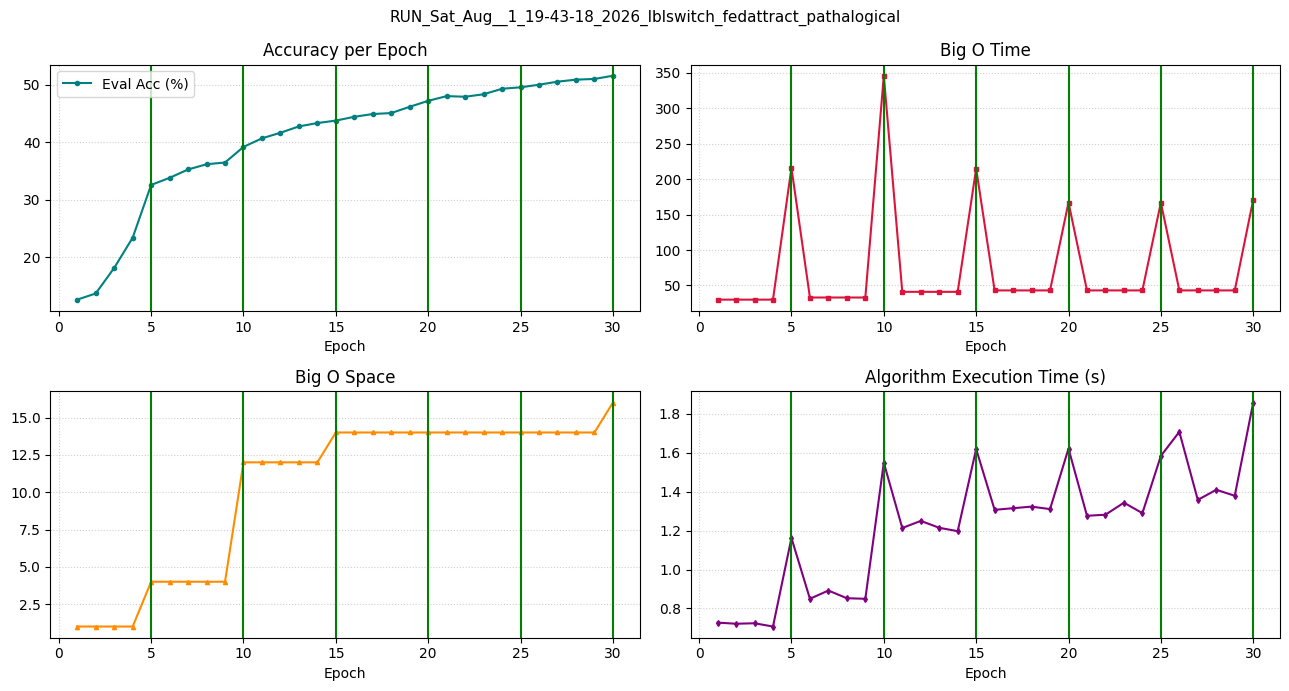

In [24]:
res1 = analyze_run(attack="lblswitch", protocol="fedattract", data_type="pathalogical")

RUN: RUN_Sat_Aug__1_21-56-31_2026_lblswitch_cap_pathalogical
Configuration -> Attack: lblswitch | Protocol: cap | Data: pathalogical
-----------------------------------------------------------------
Total Clients:     30
Normal Clients:    11 (36.67%)
Malicious Clients: 19 (63.33%)


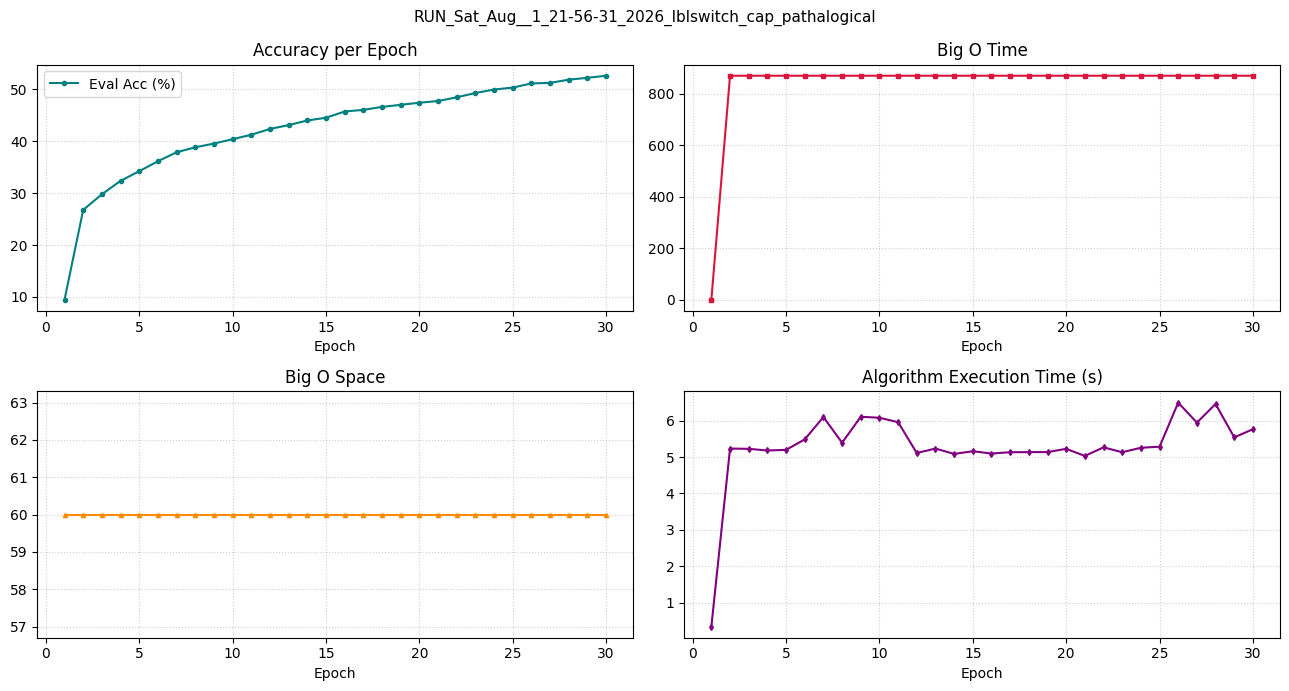

In [25]:
res = analyze_run(attack="lblswitch", protocol="cap", data_type="pathalogical")